In [107]:
# dubins car example with unconstrained reach-avoid controller

In [108]:
# Load the computed unconstrained reach-avoid controller
import sympy as sp

from sop_bounded_control_unconstrained_controller_20260315_185542 import (
    u_opt,
    certificate_opt,
    k1_opt,
)

u_opt = sp.Matrix(u_opt)
k1_opt = sp.Matrix(k1_opt)

print("Symbols in u_opt[0]:", u_opt[0].free_symbols)
print("Symbols in u_opt[1]:", u_opt[1].free_symbols)
print("Symbols in certificate_opt:", certificate_opt.free_symbols)

Symbols in u_opt[0]: {th, x1, v, x2}
Symbols in u_opt[1]: {th, x1, v, x2}
Symbols in certificate_opt: {th, x1, v, x2}


In [109]:
import numpy as np

# ── Symbolic variables ────────────────────────────────────────────────────────
x1, x2, th, v = sp.symbols("x1 x2 th v")
y1, y2 = sp.symbols("y1 y2")

state_vars = [x1, x2, th, v]  # state ordering used throughout

# ── Dubins-car dynamics:  xdot = f(x) + g(x)*u ───────────────────────────────
#   state  = [x1, x2, th, v]    (position, heading, speed)
#   control = [u1, u2]          (angular-velocity, acceleration)
f_sym = sp.Matrix([v * sp.cos(th), v * sp.sin(th), 0, 0])
g_sym = sp.Matrix([[0, 0], [0, 0], [1, 0], [0, 1]])

# ── Output map:  y = h(x) = [x1, x2]  (position) ────────────────────────────
hx = sp.Matrix([x1, x2])

# ── Sets in output (y) space ─────────────────────────────────────────────────
#   safe_set >= 0  ↔  state is in the safe region
#   target_set <= 0  ↔  state reached the target
h_raw = -(y1**4 + y2**4 - 16) * (y1**4 + y2**4 - 4)
target_set_y = (y2 - 0) ** 2 + (2 * (y1 + 1.7)) ** 2 - 0.4
alpha = 1e-3 * (-target_set_y + 300)
safe_set_y = alpha * h_raw
k1_func = sp.lambdify([y1, y2], list(k1_opt), "numpy")  # still in y-space

# ── Pull sets back to state space via h(x) ───────────────────────────────────
safe_set_x = safe_set_y.subs({y1: hx[0], y2: hx[1]})
target_set_x = target_set_y.subs({y1: hx[0], y2: hx[1]})

print("h(x):", hx.T)
print("safe_set   (y):", safe_set_y)
print("target_set (y):", target_set_y)

h(x): Matrix([[x1, x2]])
safe_set   (y): (-y1**4 - y2**4 + 16)*(y1**4 + y2**4 - 4)*(-0.001*y2**2 - 0.001*(2*y1 + 3.4)**2 + 0.3004)
target_set (y): y2**2 + (2*y1 + 3.4)**2 - 0.4


In [110]:
# ── Sample the 4-D state space and filter valid initial conditions ────────────
N_samples = 500
np.random.seed(42)

# Sampling bounds: [x1, x2, th, v]
# from bound_min = [-2, -2, 2pi/3, -1],  bound_max = [2, 2, 4pi/3, 1]
lower_bound = np.array([-2.0, -2.0, 2 * np.pi / 3, -1.0])
upper_bound = np.array([2.0, 2.0, 4 * np.pi / 3, 1.0])

x_samples = np.random.rand(4, N_samples) * (upper_bound - lower_bound).reshape(
    -1, 1
) + lower_bound.reshape(-1, 1)

# Lambdify the certificate and target-set function
certificate_func = sp.lambdify(state_vars, certificate_opt, "numpy")
safe_set_x_func = sp.lambdify(state_vars, safe_set_x, "numpy")
target_set_x_func = sp.lambdify(state_vars, target_set_x, "numpy")

cert_vals = np.atleast_1d(np.squeeze(certificate_func(*x_samples)))
target_vals = np.atleast_1d(np.squeeze(target_set_x_func(*x_samples)))

if cert_vals.shape == ():
    cert_vals = np.full(N_samples, float(cert_vals))
if target_vals.shape == ():
    target_vals = np.full(N_samples, float(target_vals))

# Valid: inside the reach-avoid certificate level set, but not already at target
valid_idx = np.where((cert_vals >= 0) & (target_vals > 0))[0]
x_valid = x_samples[:, valid_idx]

print(
    f"Sampled: {N_samples} | Valid: {len(valid_idx)} ({100*len(valid_idx)/N_samples:.1f}%)"
)
names = ["x1", "x2", "th", "v"]
for i, n in enumerate(names):
    print(f"  {n}: [{x_valid[i].min():.3f}, {x_valid[i].max():.3f}]")

Sampled: 500 | Valid: 204 (40.8%)
  x1: [-1.978, 1.960]
  x2: [-1.948, 1.949]
  th: [2.106, 4.188]
  v: [-0.964, 0.993]


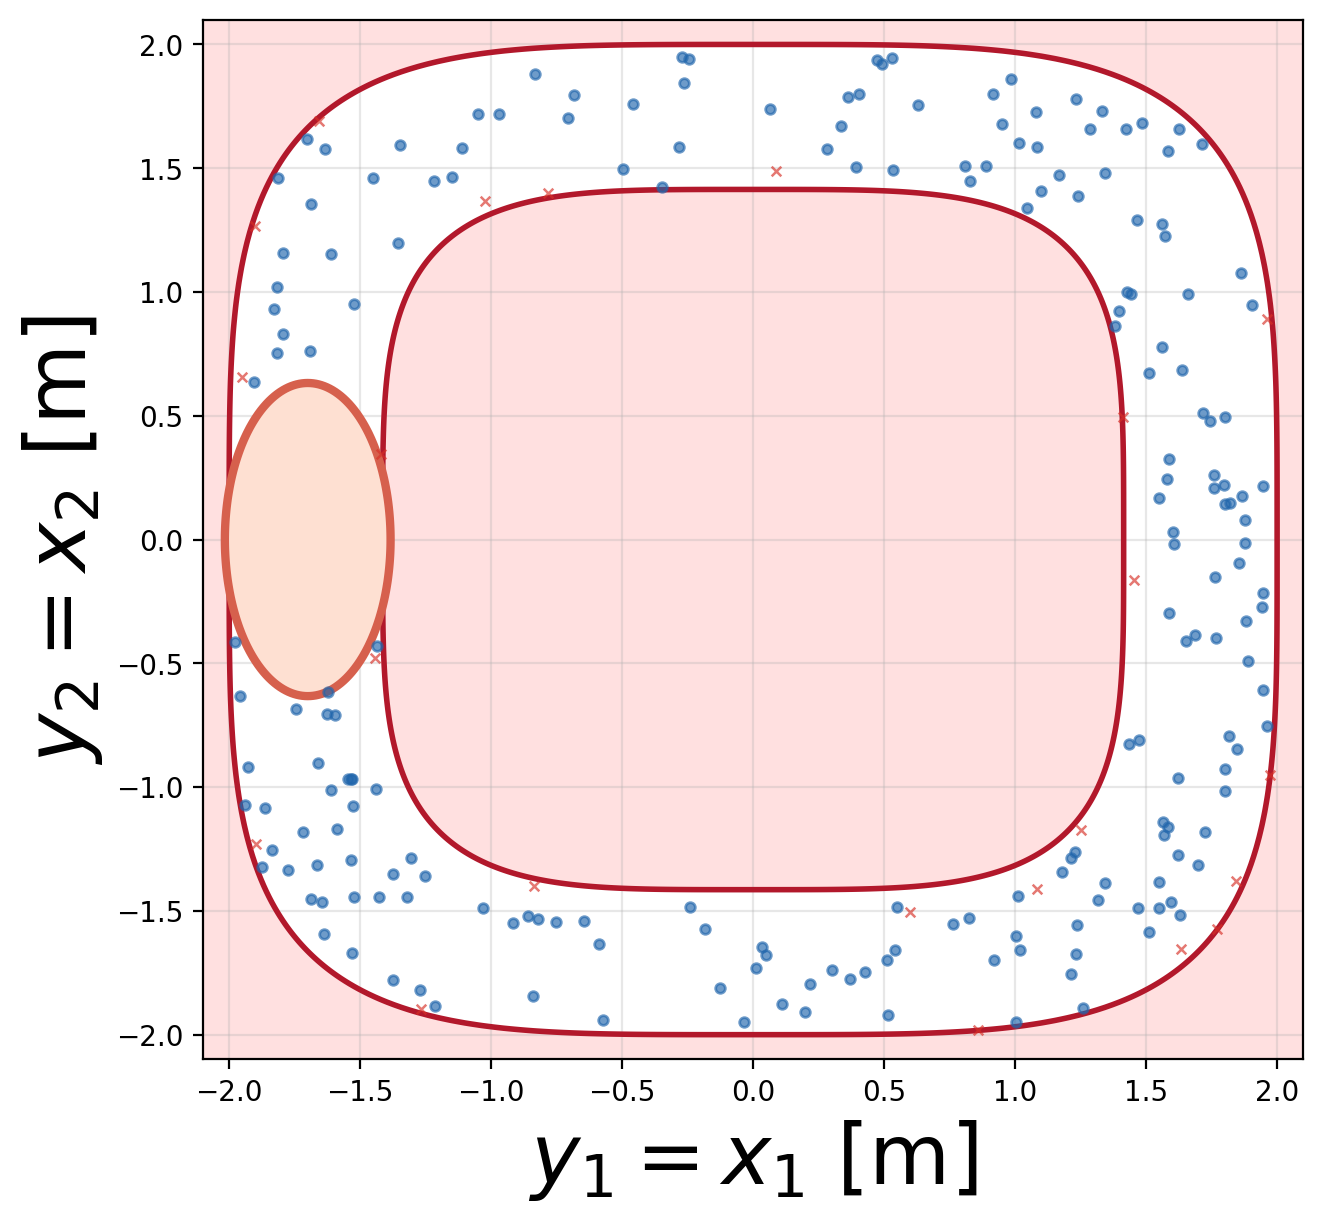

In [111]:
# ── Visualise valid/invalid initial states projected to output space (y = [x1, x2]) ──
import matplotlib.pyplot as plt

hx_func = sp.lambdify(state_vars, hx, "numpy")
safe_set_y_func = sp.lambdify([y1, y2], safe_set_y, "numpy")
target_set_y_func = sp.lambdify([y1, y2], target_set_y, "numpy")

safe_set_x_func = sp.lambdify(state_vars, safe_set_x, "numpy")

safe_vals = np.atleast_1d(np.squeeze(safe_set_x_func(*x_samples)))

# All candidates: inside safe set AND outside target set
candidate_mask = (safe_vals >= 0) & (target_vals > 0)
feasible_idx = np.where(candidate_mask & (cert_vals >= 0))[0]
infeasible_idx = np.where(candidate_mask & (cert_vals < 0))[0]

y_feasible = np.array(hx_func(*x_samples[:, feasible_idx])).reshape(2, -1)
y_infeasible = np.array(hx_func(*x_samples[:, infeasible_idx])).reshape(2, -1)

# ── Grid for set boundaries ───────────────────────────────────────────────────
n_grid = 400
y1_g = np.linspace(-2.1, 2.1, n_grid)
y2_g = np.linspace(-2.1, 2.1, n_grid)
Y1, Y2 = np.meshgrid(y1_g, y2_g)
Z_safe = safe_set_y_func(Y1, Y2)
Z_target = target_set_y_func(Y1, Y2)

px_fig = 1 / plt.rcParams["figure.dpi"]
fig, ax = plt.subplots(figsize=(650 * px_fig, 600 * px_fig), layout="constrained")
fig.set_dpi(200)

# Unsafe region (safe_set < 0)
ax.contourf(
    Y1, Y2, Z_safe, levels=[-np.inf, 0], colors=["#ffcccc"], alpha=0.6, zorder=1
)
ax.contour(Y1, Y2, Z_safe, levels=[0], colors=["#b2182b"], linewidths=2, zorder=2)
# Target region (target_set <= 0)
ax.contourf(
    Y1, Y2, Z_target, levels=[-np.inf, 0], colors=["#fee0d2"], alpha=1.0, zorder=3
)
ax.contour(Y1, Y2, Z_target, levels=[0], colors=["#d6604d"], linewidths=3, zorder=4)

# Infeasible: inside safe set, outside target, cert < 0
ax.scatter(
    y_infeasible[0],
    y_infeasible[1],
    s=12,
    color="#d73027",
    alpha=0.65,
    marker="x",
    linewidths=0.9,
    label=f"Infeasible (cert < 0): {len(infeasible_idx)}",
    zorder=9,
)
# Feasible: inside safe set, outside target, cert >= 0
ax.scatter(
    y_feasible[0],
    y_feasible[1],
    s=12,
    color="#2166ac",
    alpha=0.65,
    marker="o",
    label=f"Feasible (cert ≥ 0): {len(feasible_idx)}",
    zorder=10,
)

ax.set_xlabel("$y_1 = x_1$ [m]", fontsize=30)
ax.set_ylabel("$y_2 = x_2$ [m]", fontsize=30)
# ax.set_title("Sampled initial states in output (position) space", fontsize=13)
# ax.legend(fontsize=11, loc="upper right")
ax.grid(True, alpha=0.3)
plt.show()

In [112]:
# ── Build closed-loop dynamics and lambdify ───────────────────────────────────
cl_dyn = f_sym + g_sym @ u_opt
print("Closed-loop state dimension:", cl_dyn.shape)

dyn_cl_f = sp.lambdify(state_vars, cl_dyn, "numpy")
hx_func = sp.lambdify(state_vars, hx, "numpy")
target_x_func = sp.lambdify(state_vars, target_set_x, "numpy")

Closed-loop state dimension: (4, 1)


In [113]:
from joblib import Parallel, delayed
from scipy.integrate import solve_ivp

T_max = 30.0  # maximum simulation horizon [s]
dt_plot = 0.02  # time-step used only for dense output / plotting
rtol, atol = 1e-8, 1e-10  # tight tolerances for DOP853

np.seterr(over="ignore", invalid="ignore")


def simulate_one(x0):
    """Simulate one trajectory with DOP853 (adaptive step) + terminal event."""

    def rhs(t, x):
        dxdt = np.array(dyn_cl_f(*x)).flatten()
        return dxdt if np.all(np.isfinite(dxdt)) else np.zeros(4)

    def reached_target(t, x):
        return float(np.squeeze(target_x_func(*x)))

    reached_target.terminal = True  # stop integration when phi = 0
    reached_target.direction = -1  # only when crossing from above (phi > 0 → ≤ 0)

    sol = solve_ivp(
        rhs,
        t_span=(0.0, T_max),
        y0=x0,
        method="DOP853",
        events=reached_target,
        rtol=rtol,
        atol=atol,
        dense_output=True,  # build continuous interpolant
        max_step=dt_plot,  # cap internal step for smooth curves
    )

    # status: 0 = reached t_end, 1 = terminal event fired, <0 = failure
    if sol.status < 0 or not np.all(np.isfinite(sol.y)):
        return None

    # Evaluate the dense interpolant at uniform output times
    t_out = np.arange(0.0, sol.t[-1] + dt_plot / 2, dt_plot)
    t_out = t_out[t_out <= sol.t[-1]]
    xs = sol.sol(t_out).T  # (N, 4)
    ys = np.array(hx_func(*xs.T)).reshape(2, -1).T  # (N, 2)

    return t_out, xs, ys


# ── Run in parallel ───────────────────────────────────────────────────────────
N_sim = min(5, x_valid.shape[1])
x_sim = x_valid[:, :N_sim]

raw = Parallel(n_jobs=-1, prefer="threads")(
    delayed(simulate_one)(x_sim[:, i]) for i in range(N_sim)
)

n_total = len(raw)
raw = [r for r in raw if r is not None]
n_ok = len(raw)
print(f"Simulated: {n_ok}/{n_total}  ({n_total - n_ok} diverged)")

if n_ok == 0:
    raise RuntimeError("All trajectories diverged — check controller.")

traj_t, traj_x, traj_y = zip(*raw)
traj_t = list(traj_t)
traj_x = list(traj_x)
traj_y = list(traj_y)

for i, (tt, tx) in enumerate(zip(traj_t, traj_x)):
    phi_f = float(np.squeeze(target_x_func(*tx[-1])))
    reached = "REACHED" if phi_f <= 0 else f"phi={phi_f:.4f}"
    print(f"  traj {i+1:2d}: T={tt[-1]:.2f}s  {len(tt)-1:4d} pts  {reached}")

Simulated: 5/5  (0 diverged)
  traj  1: T=30.00s  1500 pts  phi=48.2321
  traj  2: T=30.00s  1500 pts  phi=2.3389
  traj  3: T=13.88s   694 pts  phi=0.0119
  traj  4: T=8.30s   415 pts  phi=0.0073
  traj  5: T=9.36s   468 pts  phi=0.0040


Kept 1/5 trajectories  (removed 4: 2 hit T_max, 0 other)


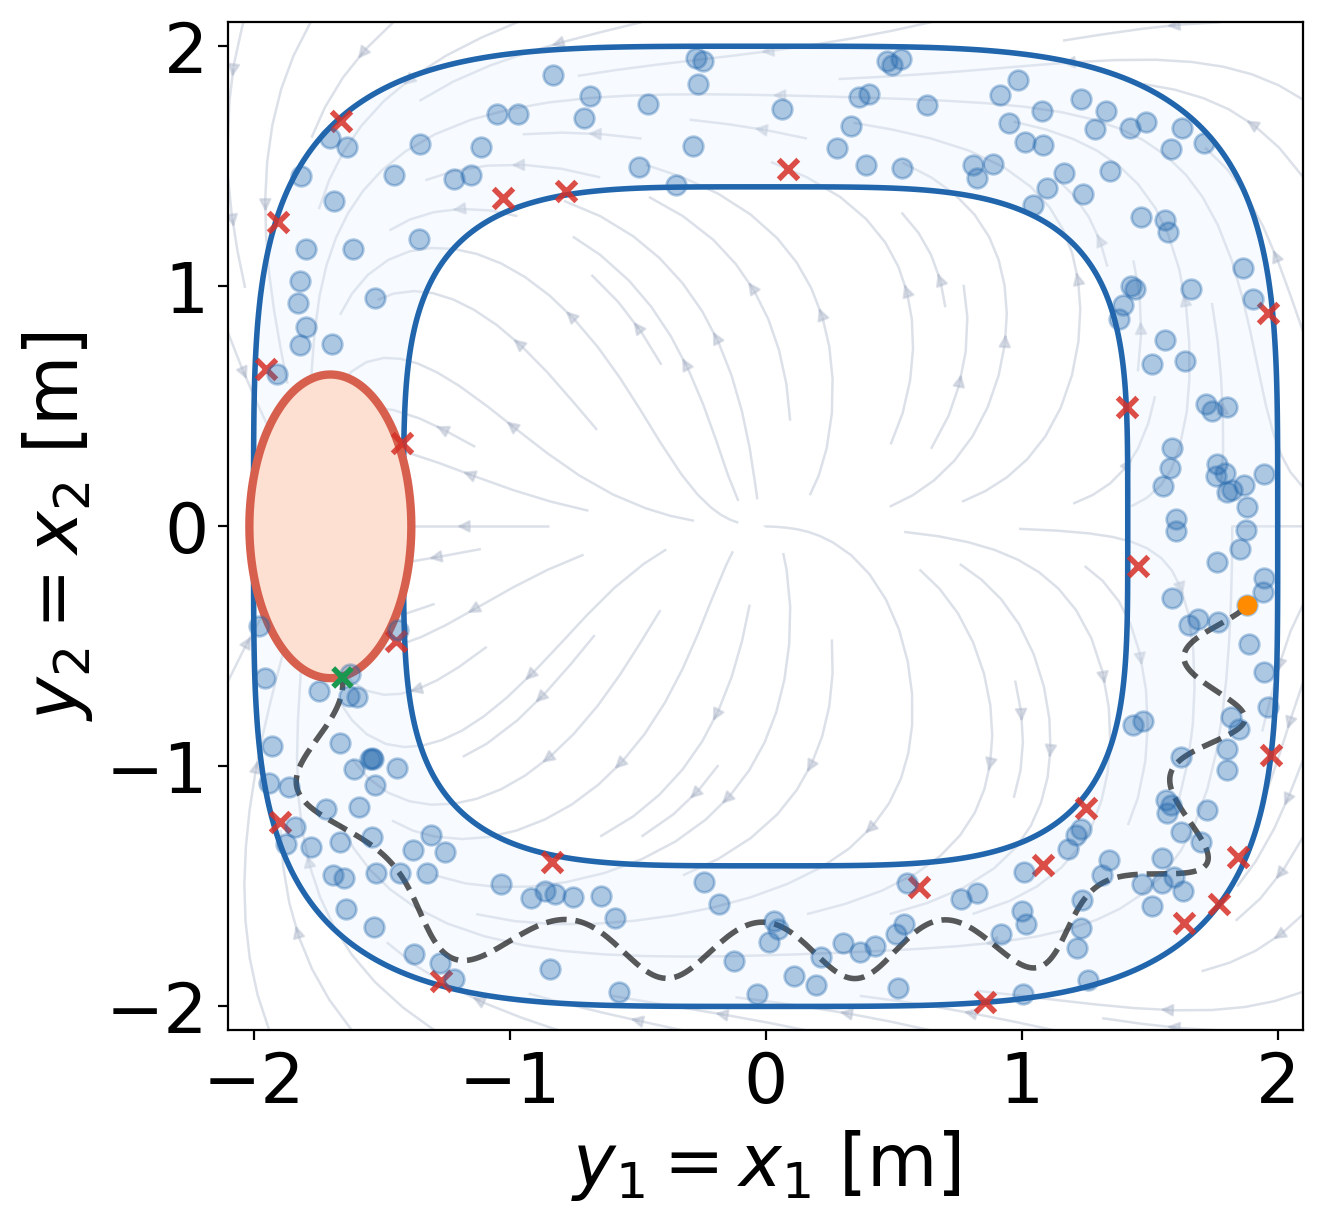

In [136]:
# ── Visualise closed-loop position trajectories + k1 vector field (y-space) ──
from functional import BetterColor

# Filter: keep only trajectories that reached the target before T_max
# and are long enough to be meaningful
T_min = 0.2  # [s] discard trajectories shorter than this
phi_tol = 0.05  # target-set tolerance: phi_final <= phi_tol counts as "reached"

filtered = [
    (tt, tx, ty)
    for tt, tx, ty in zip(traj_t, traj_x, traj_y)
    if tt[-1] < T_max - 1e-6  # did not hit the max-time wall
    and tt[-1] >= T_min  # not trivially short
    and float(np.squeeze(target_x_func(*tx[-1]))) <= phi_tol  # actually reached target
]

# only visualize 1 trajectory for now
filtered = filtered[2:3]

print(
    f"Kept {len(filtered)}/{len(traj_t)} trajectories  "
    f"(removed {len(traj_t)-len(filtered)}: "
    f"{sum(1 for tt,_,_ in zip(traj_t,traj_x,traj_y) if tt[-1] >= T_max-1e-6)} hit T_max, "
    f"{sum(1 for tt,tx,_ in zip(traj_t,traj_x,traj_y) if tt[-1]<T_max-1e-6 and (tt[-1]<T_min or float(np.squeeze(target_x_func(*tx[-1])))>phi_tol))} other)"
)

traj_t_plot, traj_x_plot, traj_y_plot = zip(*filtered) if filtered else ([], [], [])

# ─────────────────────────────────────────────────────────────────────────────
n_grid = 400
y1_g = np.linspace(-2.1, 2.1, n_grid)
y2_g = np.linspace(-2.1, 2.1, n_grid)
Y1, Y2 = np.meshgrid(y1_g, y2_g)
Z_safe_y = safe_set_y_func(Y1, Y2)
Z_target_y = target_set_y_func(Y1, Y2)

# ── k1 vector field on a coarser grid for readability ────────────────────────
n_vf = 30
y1_vf = np.linspace(-2.1, 2.1, n_vf)
y2_vf = np.linspace(-2.1, 2.1, n_vf)
VF_Y1, VF_Y2 = np.meshgrid(y1_vf, y2_vf)

k1_func = sp.lambdify([y1, y2], list(k1_opt), "numpy")
k1_vals = np.array(k1_func(VF_Y1, VF_Y2)).squeeze()  # (2, n_vf, n_vf)
U_k1 = k1_vals[0]
V_k1 = k1_vals[1]

px_fig = 1 / plt.rcParams["figure.dpi"]
fig, ax = plt.subplots(figsize=(650 * px_fig, 600 * px_fig), layout="constrained")
fig.set_dpi(200)

ax.streamplot(
    y1_vf,
    y2_vf,
    U_k1,
    V_k1,
    color=BetterColor.gray0(0.45),
    linewidth=0.9,
    density=0.9,
    arrowsize=0.9,
    zorder=1,
)

# Safe region
ax.contourf(
    Y1, Y2, Z_safe_y, levels=[0, np.inf], colors=["#e6f2ff"], alpha=0.3, zorder=1
)
ax.contour(Y1, Y2, Z_safe_y, levels=[0], colors=["#2166ac"], linewidths=2, zorder=2)
# Target region
ax.contourf(
    Y1, Y2, Z_target_y, levels=[-np.inf, 0], colors=["#fee0d2"], alpha=1.0, zorder=3
)
ax.contour(Y1, Y2, Z_target_y, levels=[0], colors=["#d6604d"], linewidths=3, zorder=4)

for ty in traj_y_plot:
    ax.plot(
        ty[:, 0], ty[:, 1], color="black", lw=2, alpha=0.65, zorder=10, linestyle="--"
    )
    ax.scatter(
        ty[0, 0],
        ty[0, 1],
        s=45,
        c=[BetterColor.orange3()],
        marker="o",
        linewidths=0.4,
        zorder=20,
    )
    ax.scatter(
        ty[-1, 0],
        ty[-1, 1],
        s=45,
        c=[BetterColor.green0()],
        marker="x",
        linewidths=2.0,
        zorder=20,
    )

# Infeasible: inside safe set, outside target, cert < 0
ax.scatter(
    y_infeasible[0],
    y_infeasible[1],
    s=50,
    color="#d73027",
    alpha=0.85,
    marker="x",
    linewidths=2,
    label=f"Infeasible (cert < 0): {len(infeasible_idx)}",
    zorder=9,
)
# Feasible: inside safe set, outside target, cert >= 0
ax.scatter(
    y_feasible[0],
    y_feasible[1],
    s=50,
    color="#2166ac",
    alpha=0.35,
    marker="o",
    label=f"Feasible (cert ≥ 0): {len(feasible_idx)}",
    zorder=10,
)

fs = 30
ax.set_xlabel("$y_1 = x_1$ [m]", fontsize=fs - 4)
ax.set_ylabel("$y_2 = x_2$ [m]", fontsize=fs - 4)
ax.xaxis.set_tick_params(labelsize=25)
ax.yaxis.set_tick_params(labelsize=25)
# ax.grid(True, alpha=0.3)
# ax.set_title(
#     f"Closed-loop trajectories ({len(filtered)} shown) + $k_1(y)$ vector field",
#     fontsize=11,
# )
plt.show()

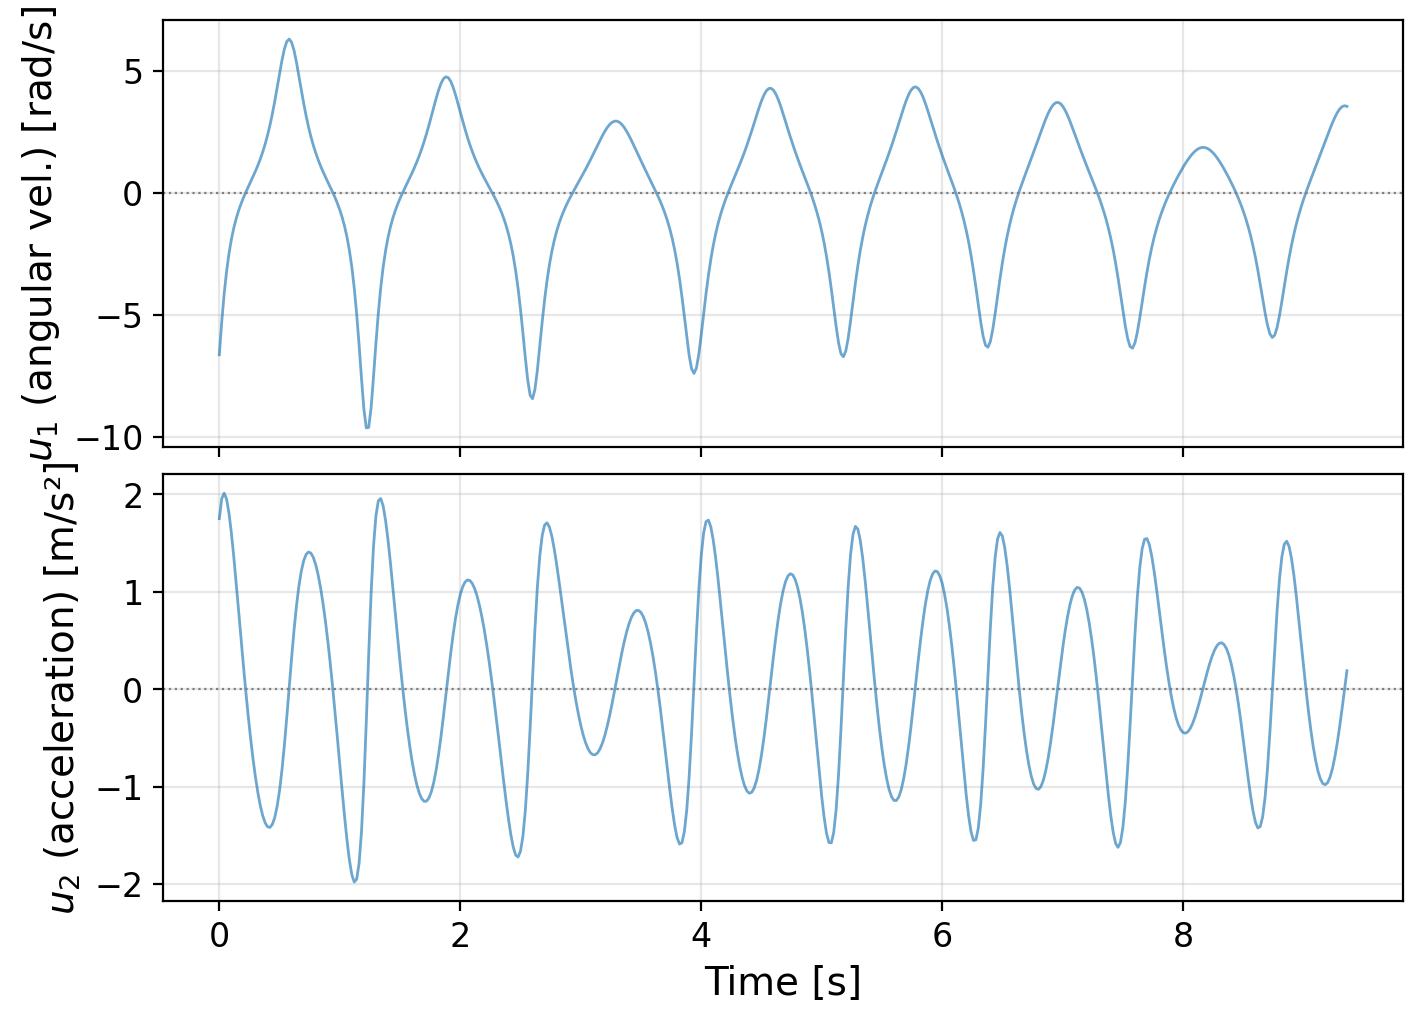

In [141]:
# ── Control inputs u1 (angular velocity) and u2 (acceleration) ───────────────
# Uses the same filtered trajectory set as the position plot (cell 8)
u1_func = sp.lambdify(state_vars, u_opt[0], "numpy")
u2_func = sp.lambdify(state_vars, u_opt[1], "numpy")

px_fig = 1 / plt.rcParams["figure.dpi"]
fig, axes = plt.subplots(
    2, 1, figsize=(700 * px_fig, 500 * px_fig), layout="constrained", sharex=True
)
fig.set_dpi(200)

for tt, tx in zip(traj_t_plot, traj_x_plot):
    axes[0].plot(tt, np.array(u1_func(*tx.T)).flatten(), lw=1.0, alpha=0.65)
    axes[1].plot(tt, np.array(u2_func(*tx.T)).flatten(), lw=1.0, alpha=0.65)

for ax, lbl in zip(
    axes, ["$u_1$ (angular vel.) [rad/s]", "$u_2$ (acceleration) [m/s²]"]
):
    ax.axhline(0, color="gray", lw=0.8, ls=":")
    ax.set_ylabel(lbl, fontsize=14)
    ax.tick_params(labelsize=12)
    ax.grid(True, alpha=0.3)

axes[1].set_xlabel("Time [s]", fontsize=14)
# fig.suptitle(
#     f"Control inputs along closed-loop trajectories ({len(traj_t_plot)} shown)",
#     fontsize=13,
# )
plt.show()

/var/folders/98/l4vl60j93tg9_xs4dt8kbvy40000gn/T/ipykernel_91730/125462426.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9, loc="upper right")


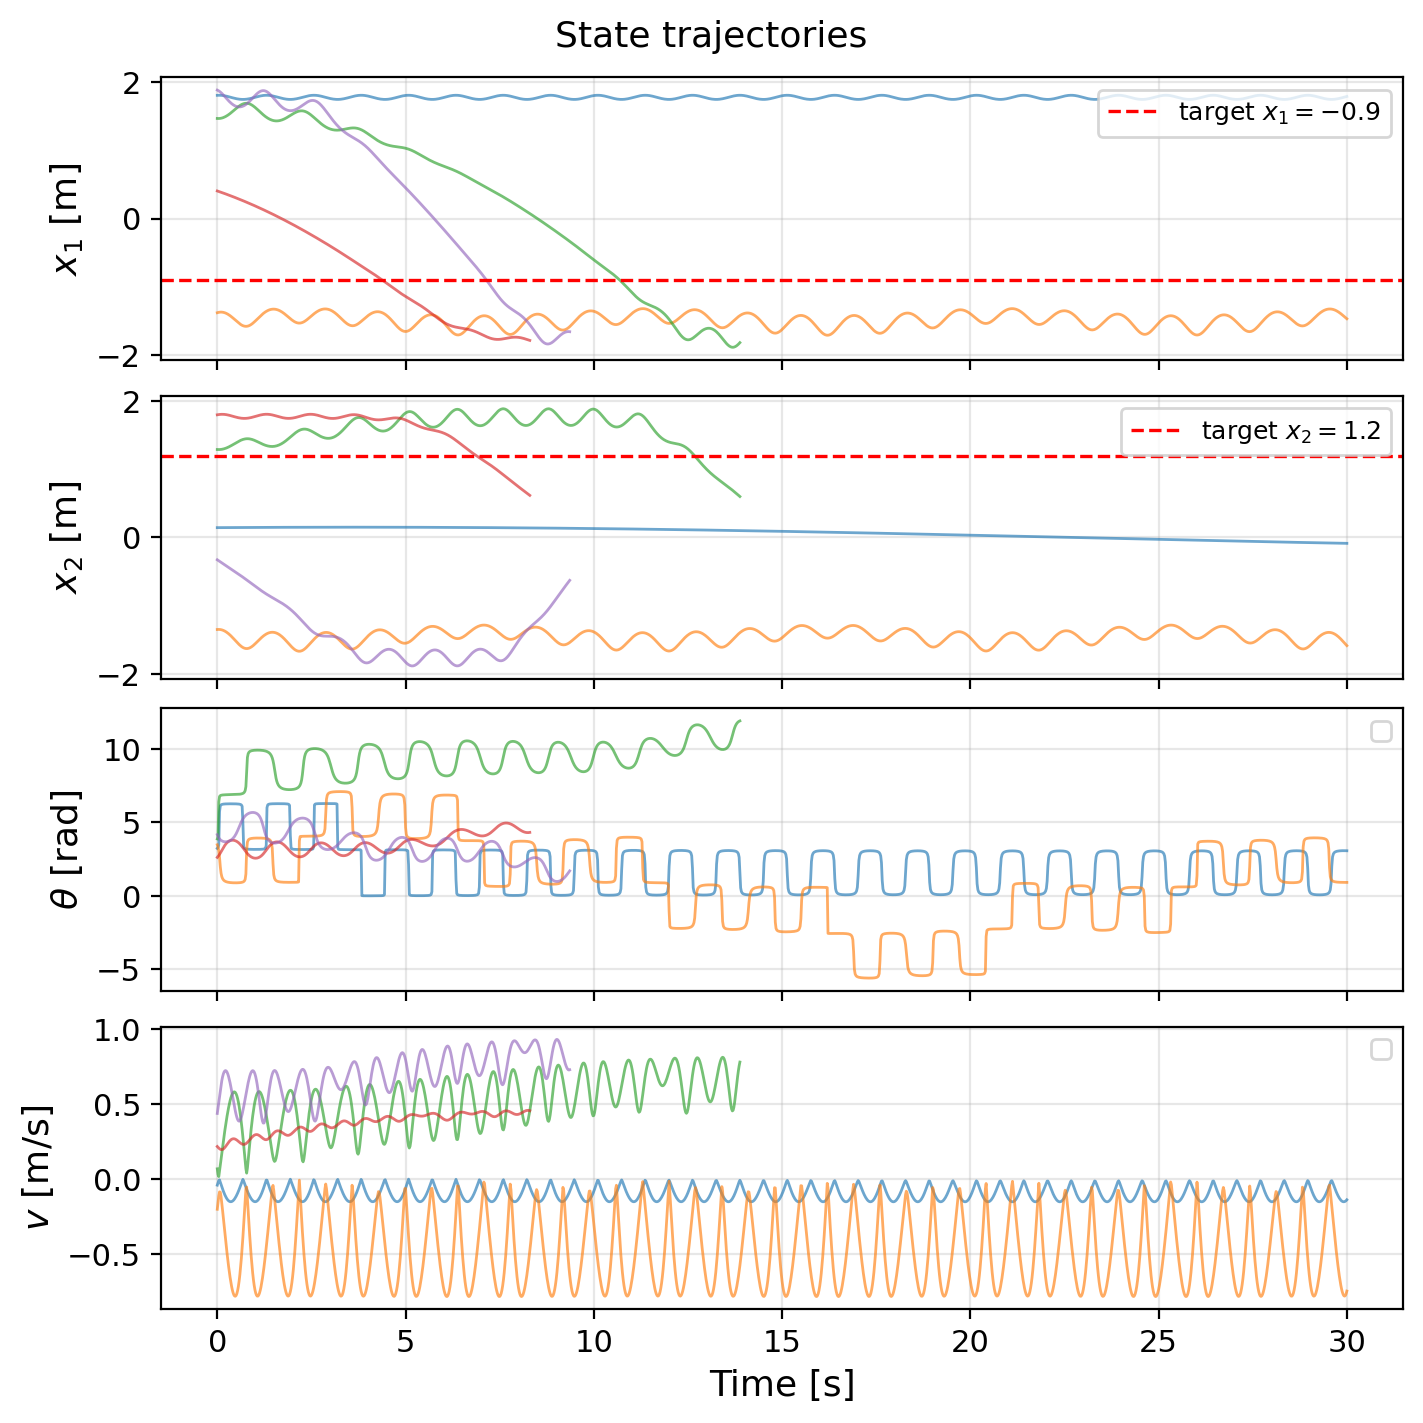

In [139]:
# ── State trajectories: positions, heading, speed ─────────────────────────────
px_fig = 1 / plt.rcParams["figure.dpi"]
fig, axes = plt.subplots(
    4, 1, figsize=(700 * px_fig, 700 * px_fig), layout="constrained", sharex=True
)
fig.set_dpi(200)

labels = ["$x_1$ [m]", "$x_2$ [m]", "$\\theta$ [rad]", "$v$ [m/s]"]

for tt, tx in zip(traj_t, traj_x):
    for i, ax in enumerate(axes):
        ax.plot(tt, tx[:, i], lw=1.0, alpha=0.65)

axes[0].axhline(-0.9, color="red", lw=1.2, ls="--", label="target $x_1 = -0.9$")
axes[1].axhline(1.2, color="red", lw=1.2, ls="--", label="target $x_2 = 1.2$")

for ax, lbl in zip(axes, labels):
    ax.set_ylabel(lbl, fontsize=13)
    ax.tick_params(labelsize=11)
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time [s]", fontsize=13)
fig.suptitle("State trajectories", fontsize=13)
plt.show()

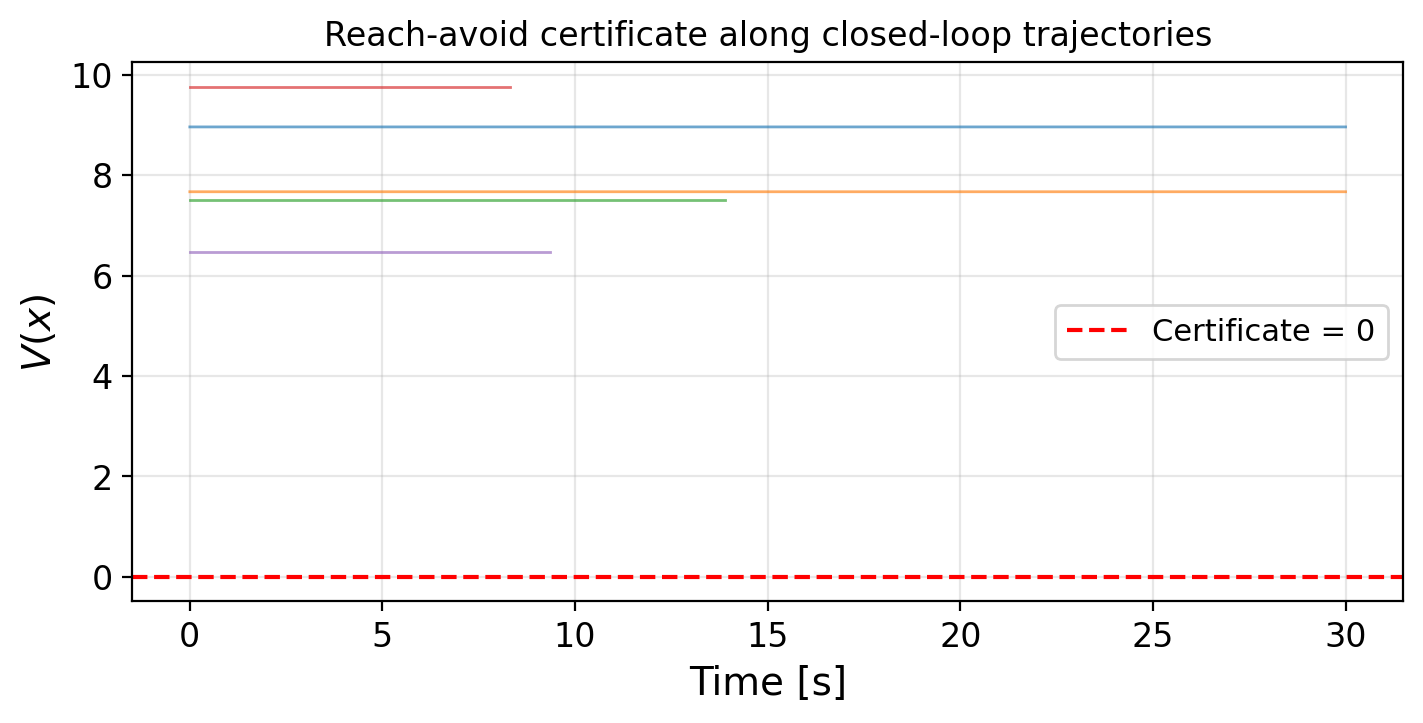

In [140]:
# ── Certificate value along trajectories (should stay >= 0) ──────────────────
px_fig = 1 / plt.rcParams["figure.dpi"]
fig, ax = plt.subplots(figsize=(700 * px_fig, 350 * px_fig), layout="constrained")
fig.set_dpi(200)

for tt, tx in zip(traj_t, traj_x):
    cert = np.array(certificate_func(*tx.T)).flatten()
    ax.plot(tt, cert, lw=1.0, alpha=0.65)

ax.axhline(0, color="red", lw=1.5, ls="--", label="Certificate = 0")
ax.set_xlabel("Time [s]", fontsize=14)
ax.set_ylabel("$V(x)$", fontsize=14)
ax.set_title("Reach-avoid certificate along closed-loop trajectories", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=12)
plt.show()